# Dev notebook — ext_forecast.py (Tầng 1: SGDRegressor online, thay LaSVM)

Notebook này **import thẳng từ `ext_forecast.py`** (không định nghĩa lại). Cần có `/tmp/aqi` (output Pha 2) trước.

Sửa `ext_forecast.py` xong, chạy lại cell là thấy ngay nhờ `%autoreload 2`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from ext_forecast import (
    build_forecast_features, time_based_split, train_sgd_online, evaluate,
    train_random_forest, evaluate_rf, print_feature_importances,
    FEATURE_COLS, TARGET_COL,
)

spark = (
    SparkSession.builder.appName("ext_forecast_dev").master("local[*]")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.driver.memory", "2g")  # Random Forest (Tang 2) can nhieu hon 1g mac dinh
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

AQI_INPUT = "/tmp/aqi"  # output cua phase2_aqi.py

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/14 22:21:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Bước 0 — đọc output Pha 2

In [2]:
df = spark.read.parquet(AQI_INPUT)
print("so dong:", df.count())

so dong: 10800


## Bước 1 — `build_forecast_features()`: lag 1h/3h/24h + target (AQI 24h sau)

In [3]:
features = build_forecast_features(df).cache()
print("so dong co du feature+label:", features.count())
features.select("station_id", "chunk_month", *FEATURE_COLS, TARGET_COL).show(5)

so dong co du feature+label: 9088


+----------+-------------------+----------+----------+-----------+-----+-----+-----+----+----+------+-----------+-----+-------+--------+--------------+
|station_id|        chunk_month|aqi_lag_1h|aqi_lag_3h|aqi_lag_24h|pm2_5| pm10|   o3| no2| so2|    co|hour_of_day|month|    lat|     lon|target_aqi_24h|
+----------+-------------------+----------+----------+-----------+-----+-----+-----+----+----+------+-----------+-----+-------+--------+--------------+
| VN_HCM_01|2026-06-01 00:00:00|      20.0|      22.0|        7.0| 9.56|11.96|26.45|1.79|0.77| 99.21|          0|    6|10.8231|106.6297|           8.0|
| VN_HCM_01|2026-06-01 00:00:00|      20.0|      20.0|       12.0| 9.24|11.84|28.13|4.15| 0.3| 80.22|          1|    6|10.8231|106.6297|          10.0|
| VN_HCM_01|2026-06-01 00:00:00|      19.0|      20.0|       14.0| 8.55|10.04|33.81|2.12| 0.3|344.48|          2|    6|10.8231|106.6297|           8.0|
| VN_HCM_01|2026-06-01 00:00:00|      19.0|      20.0|       13.0|  7.4|10.16|37.25|3.75

## Bước 2 — chia train/test THEO THỜI GIAN (không random)

In [4]:
train_months, test_months = time_based_split(features)

Train: 3 tháng (2026-06-01 07:00:00..2026-08-01 07:00:00) | Test: 1 tháng (2026-09-01 07:00:00..2026-09-01 07:00:00)


## Bước 3 — train online (partial_fit tuần tự theo tháng) + đánh giá

In [5]:
model, scaler = train_sgd_online(features, train_months)
metrics = evaluate(model, scaler, features, test_months)
print(f"RMSE={metrics['rmse']:.2f}  MAE={metrics['mae']:.2f}  R2={metrics['r2']:.4f}  (n_test={metrics['n_test']})")

  epoch 1/30 xong (3 tháng)


  epoch 2/30 xong (3 tháng)


  epoch 3/30 xong (3 tháng)


  epoch 4/30 xong (3 tháng)


  epoch 5/30 xong (3 tháng)


...

  epoch 26/30 xong (3 tháng)


  epoch 27/30 xong (3 tháng)


  epoch 28/30 xong (3 tháng)


  epoch 29/30 xong (3 tháng)


  epoch 30/30 xong (3 tháng)
RMSE=32.05  MAE=20.56  R2=0.5382  (n_test=1154)


## Bước 4 — xem thử dự báo vs thực tế trên 1 trạm (kiểm tra trực quan)

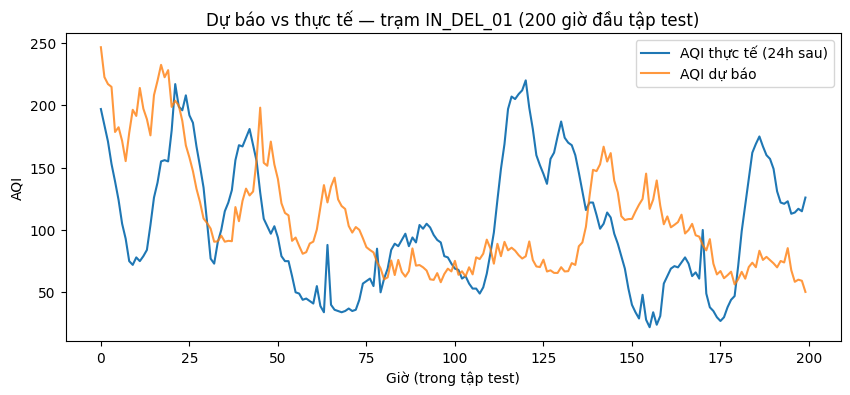

In [6]:
import matplotlib.pyplot as plt

test_pdf = (
    features.filter(F.col("chunk_month").isin(test_months))
    .orderBy("station_id", "chunk_month")
    .toPandas()
)
one_station = test_pdf[test_pdf["station_id"] == test_pdf["station_id"].iloc[0]].reset_index(drop=True)

X = scaler.transform(one_station[FEATURE_COLS].values)
y_true = one_station[TARGET_COL].values
y_pred = model.predict(X)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_true[:200], label="AQI thực tế (24h sau)")
ax.plot(y_pred[:200], label="AQI dự báo", alpha=0.8)
ax.set_title(f"Dự báo vs thực tế — trạm {one_station['station_id'].iloc[0]} (200 giờ đầu tập test)")
ax.set_xlabel("Giờ (trong tập test)")
ax.set_ylabel("AQI")
ax.legend()
plt.show()

## Bước 5 — Tầng 2: Random Forest (train phân tán thật, không chunk theo tháng)

In [7]:
train_df = features.filter(F.col("chunk_month").isin(train_months))
test_df = features.filter(F.col("chunk_month").isin(test_months))

rf_model, assembler = train_random_forest(train_df)
rf_metrics = evaluate_rf(rf_model, assembler, test_df)

print("=== So sánh Tầng 1 (SGD) vs Tầng 2 (Random Forest) ===")
print(f"{'':<12}{'RMSE':>10}{'MAE':>10}{'R2':>10}")
print(f"{'SGD (T1)':<12}{metrics['rmse']:>10.2f}{metrics['mae']:>10.2f}{metrics['r2']:>10.4f}")
print(f"{'RF (T2)':<12}{rf_metrics['rmse']:>10.2f}{rf_metrics['mae']:>10.2f}{rf_metrics['r2']:>10.4f}")

print_feature_importances(rf_model)

26/09/14 22:21:39 WARN DAGScheduler: Broadcasting large task binary with size 1092.6 KiB


26/09/14 22:21:43 WARN DAGScheduler: Broadcasting large task binary with size 2033.1 KiB


26/09/14 22:21:48 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB


26/09/14 22:21:59 WARN DAGScheduler: Broadcasting large task binary with size 6.4 MiB


26/09/14 22:22:10 WARN DAGScheduler: Broadcasting large task binary with size 1444.6 KiB


26/09/14 22:22:15 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB


26/09/14 22:22:31 WARN DAGScheduler: Broadcasting large task binary with size 2031.6 KiB


=== So sánh Tầng 1 (SGD) vs Tầng 2 (Random Forest) ===
                  RMSE       MAE        R2
SGD (T1)         32.05     20.56    0.5382
RF (T2)          31.87     20.64    0.5431

=== Feature importance (Random Forest) ===
  lon           : 0.2707
  pm10          : 0.1579
  pm2_5         : 0.1507
  aqi_lag_1h    : 0.1126
  aqi_lag_24h   : 0.0706
  aqi_lag_3h    : 0.0513
  so2           : 0.0360
  o3            : 0.0332
  hour_of_day   : 0.0331
  no2           : 0.0264
  co            : 0.0257
  month         : 0.0197
  lat           : 0.0121


## Ghi chú

- Kết quả trên chỉ chạy trên `data/samples/` (~4 tháng) — CHƯA phải số liệu chính thức cho báo cáo. Khi có data thật, `train_sgd_online()` sẽ có nhiều tháng hơn để lặp epoch, kỳ vọng hội tụ tốt hơn.
- Muốn thử nhanh: đổi `epochs=` khi gọi `train_sgd_online(features, train_months, epochs=...)` để xem ảnh hưởng tới R2.
- Notebook này chỉ để đọc/hiểu/debug — sửa logic thì sửa `ext_forecast.py`.